# Final Windup of **MatplotLib**

## Level - 01


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [9]:
data = {
    "name": ["Ali", "Sara", "Umar", "Hina", "Bilal"],
    "math": [58, 62, 78, 91, 55],
    "science": [70, 88, 65, 74, 60],
    "english": [90, 75, 80, 68, 72],
}

# make dataframe
df = pd.DataFrame(data)

# Add average column 
df["average"] = [(df["math"][i] + df["science"][i] + df["english"][i]) / 3 for i in range(len(df["name"]))]

print(df[df["average"] > 70])
print(df.dtypes)
print(df.shape)
print(df.describe())

   name  math  science  english    average
0   Ali    58       70       90  72.666667
1  Sara    62       88       75  75.000000
2  Umar    78       65       80  74.333333
3  Hina    91       74       68  77.666667
name        object
math         int64
science      int64
english      int64
average    float64
dtype: object
(5, 5)
            math    science    english    average
count   5.000000   5.000000   5.000000   5.000000
mean   68.800000  71.400000  77.000000  72.400000
std    15.254508  10.667708   8.485281   5.908563
min    55.000000  60.000000  68.000000  62.333333
25%    58.000000  65.000000  72.000000  72.666667
50%    62.000000  70.000000  75.000000  74.333333
75%    78.000000  74.000000  80.000000  75.000000
max    91.000000  88.000000  90.000000  77.666667


## Monthly sales chart
Level 02 medium


  months  sales
0    Jan  12000
1    Feb  15000
2    Mar  11000
3    Apr  17000
4    May  14000
5    Jun  19000


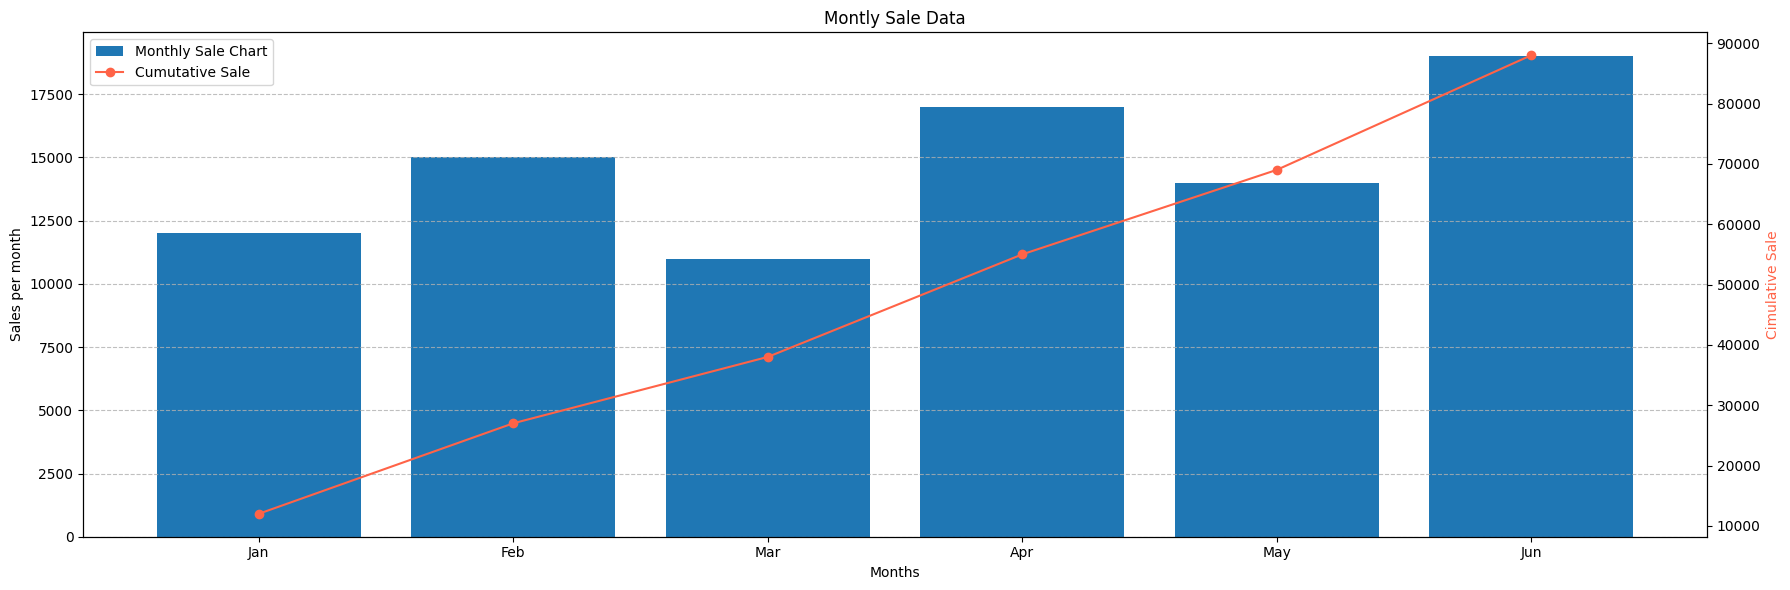

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

months = ['Jan','Feb','Mar','Apr','May','Jun']
sales  = [12000, 15000, 11000, 17000, 14000, 19000]

df = pd.DataFrame({"months" : months, "sales" : sales})
print(df)

df['comulative'] = df["sales"].cumsum()

fig, ax1 = plt.subplots(figsize = (18, 6))

ax1.bar(months, sales, label="Monthly Sale Chart")
ax1.set_xlabel("Months")
ax1.set_ylabel("Sales per month")
ax1.set_title("Montly Sale Data")
ax1.grid(axis='y', linestyle="--", alpha=0.8)

ax2 = ax1.twinx()
ax2.plot(df["months"], df["comulative"], label="Cumutative Sale", color="tomato", marker="o")
ax2.set_ylabel("Cimulative Sale", color="tomato")
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()

plt.savefig("Sale_data.png", dpi=300)
plt.show()

## Sales data analysis + multi-panel dashboard
level 03 Advance

category
Clothing       1373
Electronics    1440
Food           2058
Name: units, dtype: int64


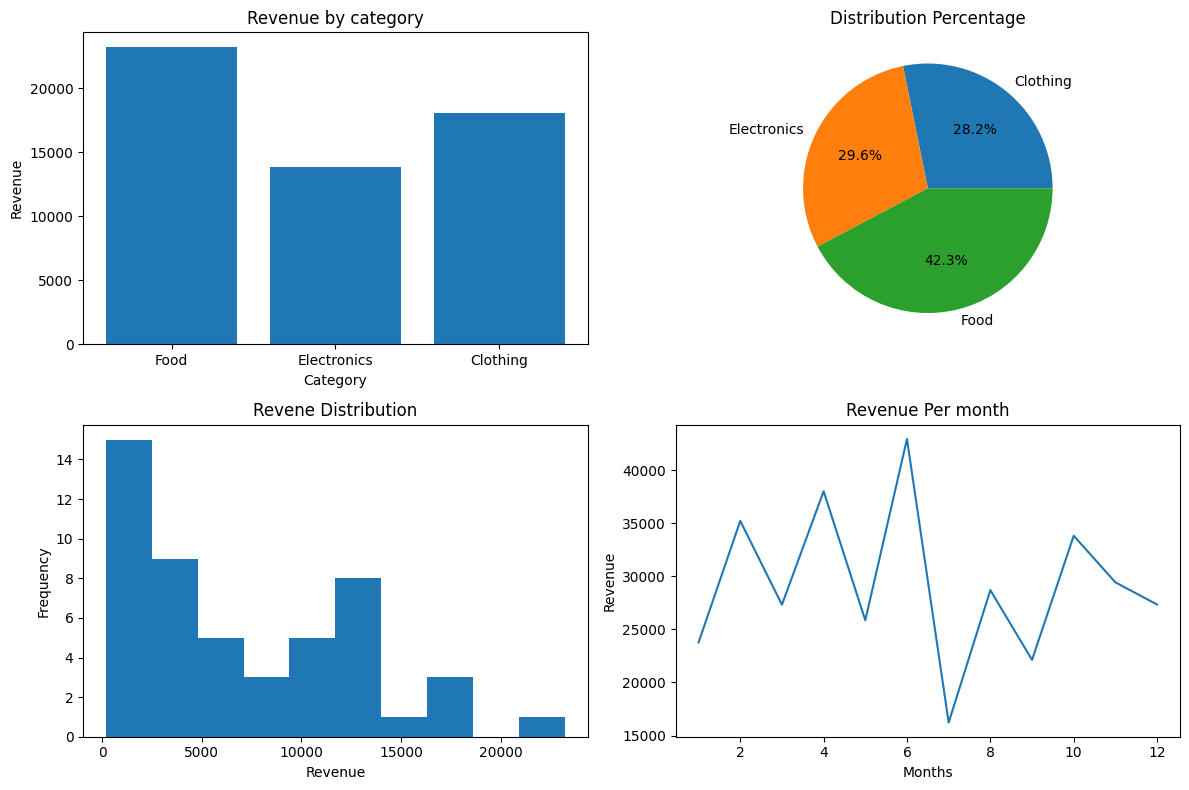

In [59]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)
n = 50
df = pd.DataFrame(
    {
        "date": pd.date_range("2024-01-01", periods=n, freq="W"),
        "category": np.random.choice(["Electronics", "Clothing", "Food"], n),
        "units": np.random.randint(10, 200, n),
        "price": np.round(np.random.uniform(5, 150, n), 2),
    }
)

df["revenue"] = df["units"] * df["price"]
df["month"] = df["date"].dt.month

category_group = df.groupby("category").agg({
    "units" : ["sum", "mean", "std"],
    "price" : ["sum", "mean", "std"],
    "revenue" : ["sum", "mean", "std"]
})


fig, ax = plt.subplots(2, 2, figsize=(12, 8))
ax[0, 0].bar(df["category"], df["revenue"], label="Revenue by category")
ax[0, 0].set_title("Revenue by category")
ax[0, 0].set_xlabel("Category")
ax[0, 0].set_ylabel("Revenue")

category_units = df.groupby("category")["units"].sum()
print(category_units)
ax[0, 1].pie(category_units, labels=category_units.index, autopct="%1.1f%%")
ax[0, 1].set_title("Distribution Percentage")

ax[1, 0].hist(df["revenue"])
ax[1, 0].set_title("Revene Distribution")
ax[1, 0].set_xlabel("Revenue")
ax[1, 0].set_ylabel("Frequency")

monthly_revenue = df.groupby("month")["revenue"].sum()
ax[1, 1].plot(monthly_revenue.index, monthly_revenue)
ax[1, 1].set_title("Revenue Per month")
ax[1, 1].set_xlabel("Months")
ax[1, 1].set_ylabel("Revenue")


plt.tight_layout()
plt.savefig("sale_revenue_graph.png")
plt.show()


